# STAR Financing Model

This notebook models STAR Bond financing with multiple revenue streams:
- **Sales + Use Tax Increment** (primary - state taxes)
- **Liquor Enforcement Tax (LET)**
- **Liquor Drink Tax / Excise**
- **Sports Wagering (APSK)**
- **Local Tax Add-Ins** (optional - Olathe, Wyandotte UG)

Adjust the parameters in the cells below to explore different scenarios.

In [1]:
# =============================================================================
# IMPORTS
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from dataclasses import dataclass
from typing import Tuple, List
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 11

---
## 1. Parameters

### Adjust these values to explore different scenarios

In [2]:
# =============================================================================
# BOND PARAMETERS
# =============================================================================

PRINCIPAL = 2_400_000_000      # Initial bond principal ($)
INTEREST_RATE = 0.05           # Annual interest rate (0.05 = 5%)
TERM_YEARS = 30                # Total bond term
COVERAGE_RATIO = 1.30          # Required coverage ratio (1.30 = 1.30x)
MAX_CAP_YEARS = 20             # Maximum capitalization period

In [3]:
# =============================================================================
# SALES + USE TAX PARAMETERS
# =============================================================================

SALES_USE_TAX_BASE = 668_000_000   # Frozen base year revenue ($)
SALES_USE_TAX_GROWTH = 0.025       # Annual growth rate (0.025 = 2.5%)

In [4]:
# =============================================================================
# LIQUOR ENFORCEMENT TAX (LET) PARAMETERS
# 8% tax on retail liquor sales
# =============================================================================

LET_BASE = 17_400_000              # Base year LET revenue ($)
LET_GROWTH = 0.02                  # Annual growth rate (0.02 = 2%)

In [5]:
# =============================================================================
# LIQUOR DRINK TAX / EXCISE PARAMETERS
# 10% state portion on drinks
# =============================================================================

LIQUOR_EXCISE_BASE = 8_200_000     # Base year excise revenue ($)
LIQUOR_EXCISE_GROWTH = 0.02        # Annual growth rate (0.02 = 2%)

In [6]:
# =============================================================================
# SPORTS WAGERING (APSK) PARAMETERS
# State's 10% privilege fee on sports betting
# =============================================================================

APSK_STATE_REVENUE = 8_700_000     # Total state sports wagering revenue ($)
APSK_PLEDGE_PCT = 0.75             # Percentage pledged to bonds (0.75 = 75%)
APSK_GROWTH = 0.03                 # Annual growth rate (0.03 = 3%)

### Local Tax Add-Ins (Optional)

These parameters represent **local** sales and use taxes from jurisdictions that could pledge their increment to support STAR bond coverage. These are in addition to the state sales/use tax increment.

**Note**: These are OPTIONAL add-ins. Set INCLUDE_LOCAL_ADD_INS = False to exclude.

In [7]:
# =============================================================================
# LOCAL TAX ADD-IN: OLATHE (Johnson County)
# =============================================================================
# Olathe is a major city in Johnson County, Kansas
# These represent local sales + use tax collections (not state)

INCLUDE_LOCAL_ADD_INS = False       # Set to False to exclude local add-ins

# Olathe Local Taxes (2024 data)
OLATHE_SALES_TAX_BASE = 49_703_253      # Local sales tax ($)
OLATHE_USE_TAX_BASE = 16_186_226        # Local use tax ($)
OLATHE_COMBINED_BASE = OLATHE_SALES_TAX_BASE + OLATHE_USE_TAX_BASE  # $65.89M
OLATHE_GROWTH = 0.035                   # Growth rate (CAGR 2021-24: ~4.1% sales, ~14% use)

In [8]:
# =============================================================================
# LOCAL TAX ADD-IN: WYANDOTTE COUNTY / KANSAS CITY, KS UNIFIED GOVERNMENT
# =============================================================================
# The Unified Government (UG) consists of:
# - Wyandotte County (county portion)
# - Kansas City, KS (city portion)
# Combined, these represent the full UG local tax base

# Wyandotte County portion (2024 data)
WYANDOTTE_CO_SALES_TAX = 32_676_896     # County local sales tax ($)
WYANDOTTE_CO_USE_TAX = 10_729_258       # County local use tax ($)

# Kansas City, KS portion (2024 data)  
KCK_SALES_TAX = 48_143_866              # City local sales tax ($)
KCK_USE_TAX = 15_518_457                # City local use tax ($)

# Combined UG
UG_SALES_TAX_BASE = WYANDOTTE_CO_SALES_TAX + KCK_SALES_TAX   # $80.82M
UG_USE_TAX_BASE = WYANDOTTE_CO_USE_TAX + KCK_USE_TAX         # $26.25M
UG_COMBINED_BASE = UG_SALES_TAX_BASE + UG_USE_TAX_BASE       # $107.07M
UG_GROWTH = 0.035                       # Growth rate (CAGR 2021-24: ~3.6% sales, ~14.6% use)

# Grand total of local add-ins
TOTAL_LOCAL_ADD_IN_BASE = OLATHE_COMBINED_BASE + UG_COMBINED_BASE  # $172.96M

print("LOCAL TAX ADD-IN SUMMARY")
print("=" * 50)
print(f"Olathe:              ${OLATHE_COMBINED_BASE/1e6:,.2f}M")
print(f"Wyandotte UG:        ${UG_COMBINED_BASE/1e6:,.2f}M")
print(f"TOTAL LOCAL ADD-IN:  ${TOTAL_LOCAL_ADD_IN_BASE/1e6:,.2f}M")
print(f"\nAs % of State Base:  {TOTAL_LOCAL_ADD_IN_BASE/SALES_USE_TAX_BASE*100:.1f}%")

LOCAL TAX ADD-IN SUMMARY
Olathe:              $65.89M
Wyandotte UG:        $107.07M
TOTAL LOCAL ADD-IN:  $172.96M

As % of State Base:  25.9%


---
## 2. Model Functions

In [9]:
# =============================================================================
# DATA CLASSES
# =============================================================================

@dataclass
class BondParams:
    """Bond structure parameters"""
    principal: float
    interest_rate: float
    term_years: int
    coverage_ratio: float
    max_cap_years: int = 20

@dataclass
class RevenueStream:
    """A single revenue stream with base and growth"""
    name: str
    base: float
    growth_rate: float
    is_increment: bool = False  # True for STAR increment (base is frozen)
    pledge_pct: float = 1.0     # Percentage pledged (for APSK)

In [10]:
# =============================================================================
# REVENUE CALCULATION FUNCTIONS
# =============================================================================

def calculate_revenue_stream(stream: RevenueStream, years: int) -> np.ndarray:
    """
    Calculate revenue for a stream over time.
    
    For STAR increment streams (is_increment=True):
        - Base is frozen, only growth above base is captured
        - Year N revenue = Base × (1+g)^N - Base
    
    For regular streams:
        - Full revenue is captured with growth
        - Year N revenue = Base × pledge_pct × (1+g)^N
    """
    t = np.arange(1, years + 1)
    
    if stream.is_increment:
        # STAR increment: only capture growth above frozen base
        total = stream.base * (1 + stream.growth_rate) ** t
        revenue = total - stream.base
    else:
        # Regular stream: capture full amount (with pledge percentage)
        revenue = stream.base * stream.pledge_pct * (1 + stream.growth_rate) ** t
    
    return revenue


def calculate_all_revenues(streams: List[RevenueStream], years: int) -> pd.DataFrame:
    """
    Calculate all revenue streams and return a DataFrame.
    """
    df = pd.DataFrame({'year': np.arange(1, years + 1)})
    
    for stream in streams:
        col_name = stream.name.lower().replace(' ', '_')
        df[col_name] = calculate_revenue_stream(stream, years)
    
    # Calculate total
    revenue_cols = [c for c in df.columns if c != 'year']
    df['total_available'] = df[revenue_cols].sum(axis=1)
    df['cumulative'] = df['total_available'].cumsum()
    
    return df

In [11]:
# =============================================================================
# DEBT SERVICE CALCULATION
# =============================================================================

def calculate_level_payment(principal: float, rate: float, periods: int) -> float:
    """
    Calculate level annual debt service (P&I) for amortizing loan.
    
    PMT = P × [r(1+r)^n] / [(1+r)^n - 1]
    """
    if rate == 0:
        return principal / periods
    return principal * (rate * (1 + rate) ** periods) / ((1 + rate) ** periods - 1)

In [12]:
# =============================================================================
# STAR FINANCING SIMULATION
# =============================================================================

def simulate_star_financing(
    bond: BondParams,
    streams: List[RevenueStream],
    max_iterations: int = 50,
    tolerance: float = 1000
) -> Tuple[pd.DataFrame, dict]:
    """
    Simulate STAR financing with capitalized interest.
    
    During capitalization period (when available revenue < required coverage):
    - Available revenue pays partial interest
    - Shortfall is capitalized (added to principal)
    
    After capitalization:
    - Level debt service payments begin
    """
    
    # Calculate all revenue streams
    revenue_df = calculate_all_revenues(streams, bond.term_years)
    available = revenue_df['total_available'].values
    
    # Iteratively solve for debt service (converges when cap period stabilizes)
    debt_service = calculate_level_payment(bond.principal, bond.interest_rate, bond.term_years)
    prev_final_principal = 0
    
    for iteration in range(max_iterations):
        principal = bond.principal
        cap_years = 0
        
        for year in range(bond.term_years):
            interest_due = principal * bond.interest_rate
            avail = available[year]
            required = debt_service * bond.coverage_ratio
            
            if year < bond.max_cap_years and avail < required:
                # Capitalize shortfall
                paid = min(avail, interest_due)
                shortfall = interest_due - paid
                principal += shortfall
                cap_years = year + 1
            else:
                break
        
        if abs(principal - prev_final_principal) < tolerance:
            break
        
        prev_final_principal = principal
        remaining = bond.term_years - cap_years
        if remaining <= 0:
            remaining = 1
        debt_service = calculate_level_payment(principal, bond.interest_rate, remaining)
    
    # Final simulation with converged parameters
    results = []
    principal = bond.principal
    capitalized_interest = 0
    
    for year in range(bond.term_years):
        interest_due = principal * bond.interest_rate
        avail = available[year]
        
        if year < cap_years:
            # Capitalization period
            interest_paid = min(avail, interest_due)
            interest_cap = interest_due - interest_paid
            principal_paid = 0
            principal += interest_cap
            capitalized_interest += interest_cap
            actual_ds = interest_paid
        else:
            # Amortization period
            interest_paid = principal * bond.interest_rate
            principal_paid = debt_service - interest_paid
            interest_cap = 0
            principal -= principal_paid
            actual_ds = debt_service
        
        coverage = avail / debt_service if debt_service > 0 else float('inf')
        
        results.append({
            'year': year + 1,
            'available_revenue': avail,
            'interest_due': interest_due if year < cap_years else interest_paid,
            'interest_paid': interest_paid,
            'interest_capitalized': interest_cap,
            'principal_paid': principal_paid,
            'debt_service': actual_ds,
            'ending_principal': max(0, principal),
            'coverage_ratio': coverage,
            'in_cap_period': year < cap_years
        })
    
    df = pd.DataFrame(results)
    
    # Merge with revenue breakdown
    df = df.merge(revenue_df, on='year')
    
    # Summary statistics
    total_interest_paid = df['interest_paid'].sum()
    total_interest = capitalized_interest + total_interest_paid
    
    summary = {
        'initial_principal': bond.principal,
        'interest_rate': bond.interest_rate,
        'term_years': bond.term_years,
        'coverage_ratio': bond.coverage_ratio,
        'capitalization_years': cap_years,
        'amortization_years': bond.term_years - cap_years,
        'principal_after_cap': bond.principal + capitalized_interest,
        'annual_debt_service': debt_service,
        'total_interest_capitalized': capitalized_interest,
        'total_interest_paid': total_interest_paid,
        'total_interest': total_interest,
        'interest_pct_of_principal': total_interest / bond.principal * 100,
        'total_revenue_30yr': df['total_available'].sum(),
        'viable': cap_years < bond.max_cap_years
    }
    
    return df, summary

---
## 3. Run the Model

In [13]:
# =============================================================================
# CREATE REVENUE STREAMS FROM PARAMETERS
# =============================================================================

revenue_streams = [
    RevenueStream(
        name='Sales_Use_Increment',
        base=SALES_USE_TAX_BASE,
        growth_rate=SALES_USE_TAX_GROWTH,
        is_increment=True  # STAR increment - only growth above base
    ),
    RevenueStream(
        name='LET',
        base=LET_BASE,
        growth_rate=LET_GROWTH
    ),
    RevenueStream(
        name='Liquor_Excise',
        base=LIQUOR_EXCISE_BASE,
        growth_rate=LIQUOR_EXCISE_GROWTH
    ),
    RevenueStream(
        name='APSK',
        base=APSK_STATE_REVENUE,
        growth_rate=APSK_GROWTH,
        pledge_pct=APSK_PLEDGE_PCT
    )
]

# Add local tax add-ins if enabled
if INCLUDE_LOCAL_ADD_INS:
    # Olathe Local Increment (STAR - only growth above frozen base)
    revenue_streams.append(
        RevenueStream(
            name='Olathe_Local',
            base=OLATHE_COMBINED_BASE,
            growth_rate=OLATHE_GROWTH,
            is_increment=True  # STAR increment
        )
    )
    
    # Wyandotte UG Local Increment (STAR - only growth above frozen base)
    revenue_streams.append(
        RevenueStream(
            name='Wyandotte_UG_Local',
            base=UG_COMBINED_BASE,
            growth_rate=UG_GROWTH,
            is_increment=True  # STAR increment
        )
    )

# Create bond parameters
bond_params = BondParams(
    principal=PRINCIPAL,
    interest_rate=INTEREST_RATE,
    term_years=TERM_YEARS,
    coverage_ratio=COVERAGE_RATIO,
    max_cap_years=MAX_CAP_YEARS
)

print("Revenue Streams:")
print("=" * 70)
for stream in revenue_streams:
    base_amt = stream.base * stream.pledge_pct
    inc_flag = " (STAR increment)" if stream.is_increment else ""
    print(f"  {stream.name:25} ${base_amt:>15,.0f}  ({stream.growth_rate:.1%} growth){inc_flag}")
print("=" * 70)
if INCLUDE_LOCAL_ADD_INS:
    print(f"\nLocal Add-Ins: INCLUDED (Olathe + Wyandotte UG = ${TOTAL_LOCAL_ADD_IN_BASE/1e6:.1f}M base)")
else:
    print("\nLocal Add-Ins: NOT INCLUDED")

Revenue Streams:
  Sales_Use_Increment       $    668,000,000  (2.5% growth) (STAR increment)
  LET                       $     17,400,000  (2.0% growth)
  Liquor_Excise             $      8,200,000  (2.0% growth)
  APSK                      $      6,525,000  (3.0% growth)

Local Add-Ins: NOT INCLUDED


In [14]:
# =============================================================================
# RUN SIMULATION
# =============================================================================

df, summary = simulate_star_financing(bond_params, revenue_streams)

print("\n" + "=" * 70)
print("STAR FINANCING MODEL RESULTS")
print("=" * 70)

print(f"""
BOND PARAMETERS
---------------
Principal:           ${summary['initial_principal']:,.0f}
Interest Rate:       {summary['interest_rate']:.2%}
Term:                {summary['term_years']} years
Coverage Ratio:      {summary['coverage_ratio']:.2f}x

RESULTS
-------
Capitalization Years:    {summary['capitalization_years']}
Amortization Years:      {summary['amortization_years']}
Principal After Cap:     ${summary['principal_after_cap']:,.0f}
Annual Debt Service:     ${summary['annual_debt_service']:,.0f}

INTEREST COSTS
--------------
Interest Capitalized:    ${summary['total_interest_capitalized']:,.0f}
Interest Paid:           ${summary['total_interest_paid']:,.0f}
TOTAL INTEREST:          ${summary['total_interest']:,.0f}
Interest as % of P:      {summary['interest_pct_of_principal']:.1f}%

30-YEAR REVENUE
---------------
Total Available:         ${summary['total_revenue_30yr']:,.0f}
""")

if summary['viable']:
    print(f"✓ VIABLE: Coverage met in Year {summary['capitalization_years'] + 1}")
else:
    print(f"⚠️  NOT VIABLE: Capitalization exceeds {MAX_CAP_YEARS} years")


STAR FINANCING MODEL RESULTS

BOND PARAMETERS
---------------
Principal:           $2,400,000,000
Interest Rate:       5.00%
Term:                30 years
Coverage Ratio:      1.30x

RESULTS
-------
Capitalization Years:    11
Amortization Years:      19
Principal After Cap:     $2,597,203,681
Annual Debt Service:     $197,310,884

INTEREST COSTS
--------------
Interest Capitalized:    $197,203,681
Interest Paid:           $2,898,768,112
TOTAL INTEREST:          $3,095,971,793
Interest as % of P:      129.0%

30-YEAR REVENUE
---------------
Total Available:         $11,399,237,015

✓ VIABLE: Coverage met in Year 12


---
## 4. Amortization Schedule

In [15]:
# =============================================================================
# DISPLAY AMORTIZATION SCHEDULE
# =============================================================================

# Format for display
schedule = df[['year', 'available_revenue', 'debt_service', 'interest_paid', 
               'interest_capitalized', 'principal_paid', 'ending_principal', 
               'coverage_ratio', 'in_cap_period']].copy()

# Show first 15 years and last 5 years
print("\nAMORTIZATION SCHEDULE (First 15 years)")
print("=" * 120)
print(f"{'Year':>5} {'Available':>15} {'Debt Svc':>15} {'Int Paid':>12} {'Int Cap':>12} {'Prin Paid':>12} {'End Prin':>15} {'Coverage':>10} {'Period':>10}")
print("-" * 120)

for _, row in schedule.head(15).iterrows():
    period = 'CAP' if row['in_cap_period'] else 'AMORT'
    print(f"{row['year']:>5} ${row['available_revenue']/1e6:>13.1f}M ${row['debt_service']/1e6:>13.1f}M "
          f"${row['interest_paid']/1e6:>10.1f}M ${row['interest_capitalized']/1e6:>10.1f}M "
          f"${row['principal_paid']/1e6:>10.1f}M ${row['ending_principal']/1e9:>13.2f}B "
          f"{row['coverage_ratio']:>9.2f}x {period:>10}")

print("\n... (middle years omitted) ...\n")

print("AMORTIZATION SCHEDULE (Last 5 years)")
print("-" * 120)
for _, row in schedule.tail(5).iterrows():
    period = 'CAP' if row['in_cap_period'] else 'AMORT'
    print(f"{row['year']:>5} ${row['available_revenue']/1e6:>13.1f}M ${row['debt_service']/1e6:>13.1f}M "
          f"${row['interest_paid']/1e6:>10.1f}M ${row['interest_capitalized']/1e6:>10.1f}M "
          f"${row['principal_paid']/1e6:>10.1f}M ${row['ending_principal']/1e9:>13.2f}B "
          f"{row['coverage_ratio']:>9.2f}x {period:>10}")


AMORTIZATION SCHEDULE (First 15 years)
 Year       Available        Debt Svc     Int Paid      Int Cap    Prin Paid        End Prin   Coverage     Period
------------------------------------------------------------------------------------------------------------------------
    1 $         49.5M $         49.5M $      49.5M $      70.5M $       0.0M $         2.47B      0.25x        CAP
    2 $         67.4M $         67.4M $      67.4M $      56.1M $       0.0M $         2.53B      0.34x        CAP
    3 $         85.7M $         85.7M $      85.7M $      40.7M $       0.0M $         2.57B      0.43x        CAP
    4 $        104.4M $        104.4M $     104.4M $      24.0M $       0.0M $         2.59B      0.53x        CAP
    5 $        123.6M $        123.6M $     123.6M $       6.0M $       0.0M $         2.60B      0.63x        CAP
    6 $        143.3M $        129.9M $     129.9M $       0.0M $       0.0M $         2.60B      0.73x        CAP
    7 $        163.5M $        129

---
## 5. Visualizations

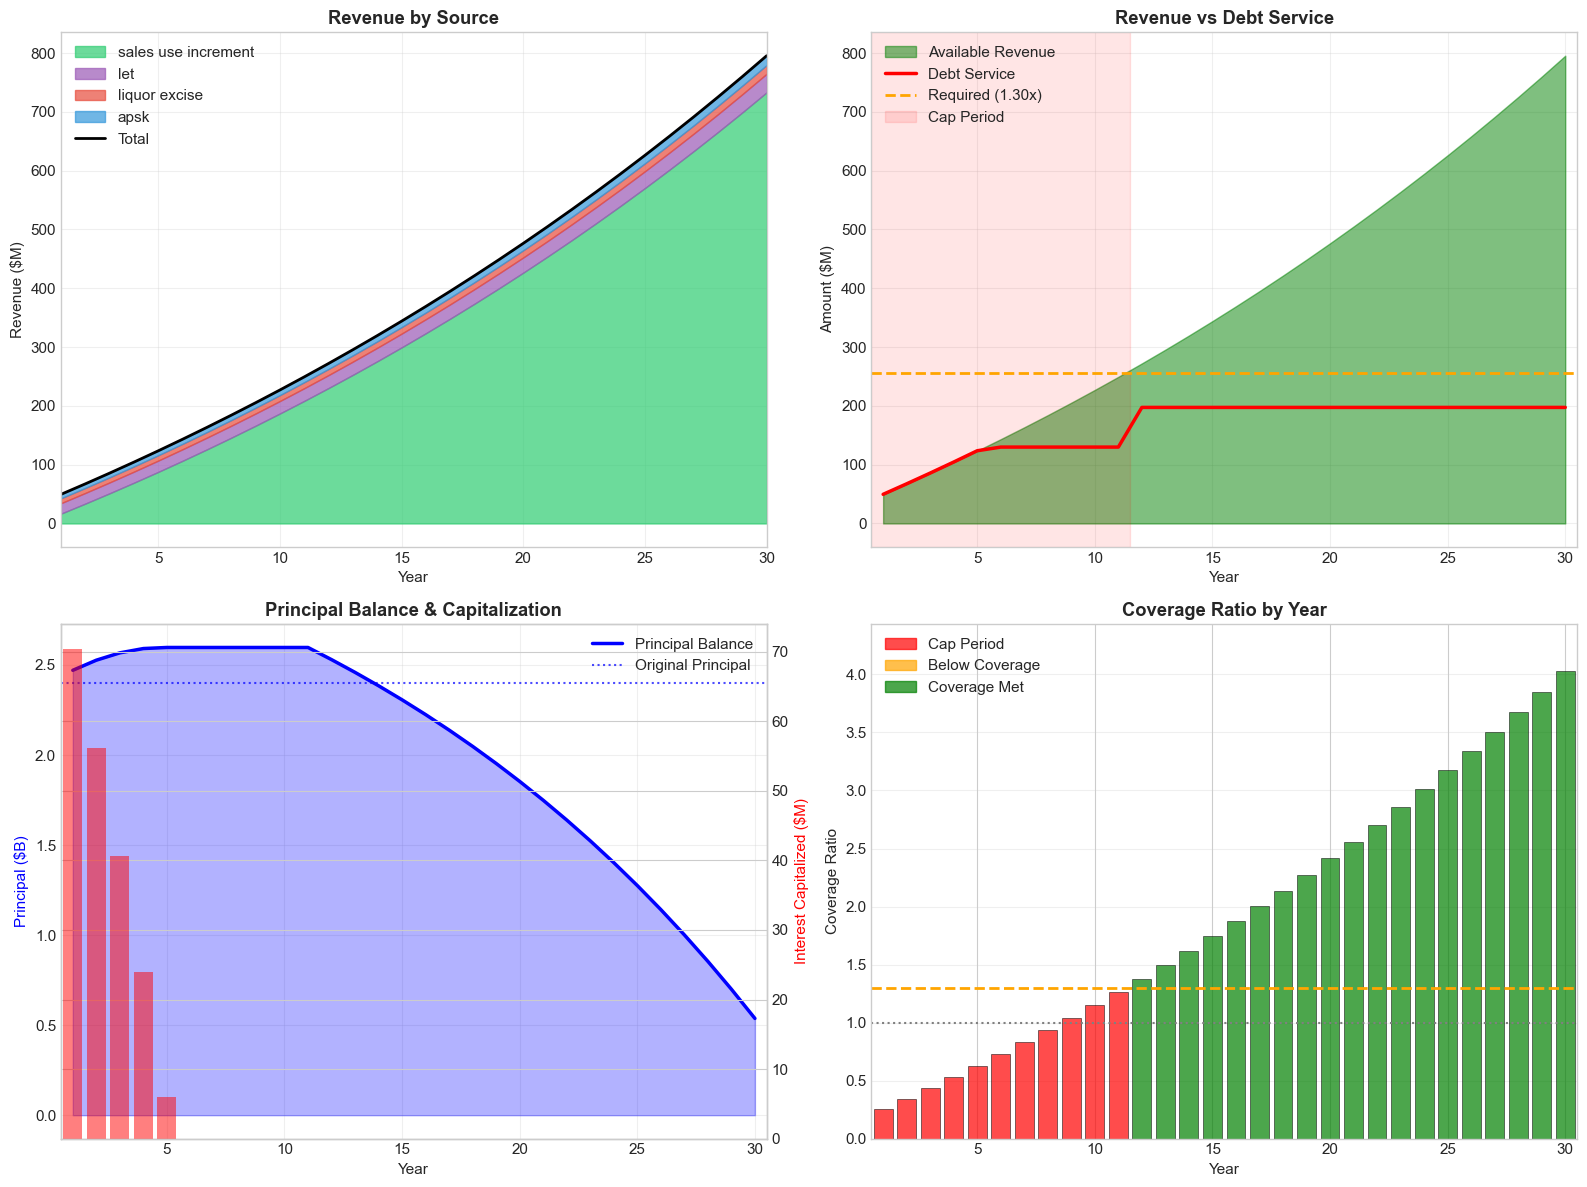


Dashboard saved to: data/star_financing_dashboard.png


In [16]:
# =============================================================================
# VISUALIZATION: 4-PANEL DASHBOARD
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

years = df['year'].values
cap_years = summary['capitalization_years']

# -----------------------------------------------------------------------------
# PLOT 1: Revenue Stack by Source
# -----------------------------------------------------------------------------
ax1 = axes[0, 0]

# Get revenue columns
rev_cols = [c for c in df.columns if c not in ['year', 'total_available', 'cumulative', 
            'available_revenue', 'interest_due', 'interest_paid', 'interest_capitalized',
            'principal_paid', 'debt_service', 'ending_principal', 'coverage_ratio', 'in_cap_period']]

colors = ['#2ecc71', '#9b59b6', '#e74c3c', '#3498db']
bottom = np.zeros(len(years))

for i, col in enumerate(rev_cols):
    values = df[col].values / 1e6
    ax1.fill_between(years, bottom, bottom + values, alpha=0.7, 
                     color=colors[i % len(colors)], label=col.replace('_', ' '))
    bottom += values

ax1.plot(years, df['total_available'].values / 1e6, 'k-', linewidth=2, label='Total')
ax1.set_xlabel('Year')
ax1.set_ylabel('Revenue ($M)')
ax1.set_title('Revenue by Source', fontweight='bold')
ax1.legend(loc='upper left')
ax1.set_xlim(1, 30)
ax1.grid(True, alpha=0.3)

# -----------------------------------------------------------------------------
# PLOT 2: Revenue vs Debt Service
# -----------------------------------------------------------------------------
ax2 = axes[0, 1]

ax2.fill_between(years, 0, df['total_available'].values / 1e6, alpha=0.5, 
                 color='green', label='Available Revenue')
ax2.plot(years, df['debt_service'].values / 1e6, 'r-', linewidth=2.5, 
         label='Debt Service')
ax2.axhline(y=summary['annual_debt_service'] * COVERAGE_RATIO / 1e6, 
            color='orange', linestyle='--', linewidth=2, 
            label=f'Required ({COVERAGE_RATIO:.2f}x)')
ax2.axvspan(0.5, cap_years + 0.5, alpha=0.1, color='red', label='Cap Period')

ax2.set_xlabel('Year')
ax2.set_ylabel('Amount ($M)')
ax2.set_title('Revenue vs Debt Service', fontweight='bold')
ax2.legend(loc='upper left')
ax2.set_xlim(0.5, 30.5)
ax2.grid(True, alpha=0.3)

# -----------------------------------------------------------------------------
# PLOT 3: Principal Balance
# -----------------------------------------------------------------------------
ax3 = axes[1, 0]

ax3.fill_between(years, 0, df['ending_principal'].values / 1e9, alpha=0.3, color='blue')
ax3.plot(years, df['ending_principal'].values / 1e9, 'b-', linewidth=2.5, 
         label='Principal Balance')
ax3.axhline(y=PRINCIPAL / 1e9, color='blue', linestyle=':', linewidth=1.5, 
            alpha=0.7, label='Original Principal')

# Add interest capitalized as bars
ax3_twin = ax3.twinx()
bar_colors = ['red' if ic > 0 else 'lightgray' for ic in df['interest_capitalized'].values]
ax3_twin.bar(years, df['interest_capitalized'].values / 1e6, alpha=0.5, 
             color=bar_colors, label='Interest Capitalized')
ax3_twin.set_ylabel('Interest Capitalized ($M)', color='red')

ax3.set_xlabel('Year')
ax3.set_ylabel('Principal ($B)', color='blue')
ax3.set_title('Principal Balance & Capitalization', fontweight='bold')
ax3.legend(loc='upper right')
ax3.set_xlim(0.5, 30.5)
ax3.grid(True, alpha=0.3)

# -----------------------------------------------------------------------------
# PLOT 4: Coverage Ratio
# -----------------------------------------------------------------------------
ax4 = axes[1, 1]

coverage = df['coverage_ratio'].values
in_cap = df['in_cap_period'].values
bar_colors = ['red' if cap else ('orange' if cov < COVERAGE_RATIO else 'green') 
              for cap, cov in zip(in_cap, coverage)]

ax4.bar(years, coverage, color=bar_colors, alpha=0.7, edgecolor='black', linewidth=0.5)
ax4.axhline(y=COVERAGE_RATIO, color='orange', linestyle='--', linewidth=2, 
            label=f'Required ({COVERAGE_RATIO:.2f}x)')
ax4.axhline(y=1.0, color='gray', linestyle=':', linewidth=1.5)

ax4.set_xlabel('Year')
ax4.set_ylabel('Coverage Ratio')
ax4.set_title('Coverage Ratio by Year', fontweight='bold')
ax4.set_xlim(0.5, 30.5)
ax4.set_ylim(0, min(5, max(coverage) * 1.1))
ax4.grid(True, alpha=0.3, axis='y')

# Legend
cap_patch = mpatches.Patch(color='red', alpha=0.7, label='Cap Period')
gap_patch = mpatches.Patch(color='orange', alpha=0.7, label='Below Coverage')
ok_patch = mpatches.Patch(color='green', alpha=0.7, label='Coverage Met')
ax4.legend(handles=[cap_patch, gap_patch, ok_patch], loc='upper left')

plt.tight_layout()
plt.savefig('data/star_financing_dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\nDashboard saved to: data/star_financing_dashboard.png")

---
## 6. Sensitivity Analysis

In [17]:
# =============================================================================
# SENSITIVITY ANALYSIS FUNCTION
# =============================================================================

def run_sensitivity_analysis(
    base_streams: List[RevenueStream],
    bond: BondParams,
    interest_rates: List[float],
    growth_rates: List[float]
) -> pd.DataFrame:
    """
    Run sensitivity analysis varying interest rate and growth rate.
    Growth rate is applied to the Sales+Use increment stream.
    """
    results = []
    
    for rate in interest_rates:
        for growth in growth_rates:
            # Create modified streams
            mod_streams = []
            for s in base_streams:
                if s.is_increment:  # Sales+Use increment
                    mod_streams.append(RevenueStream(
                        name=s.name, base=s.base, growth_rate=growth,
                        is_increment=True, pledge_pct=s.pledge_pct
                    ))
                else:
                    # Scale other growth rates proportionally
                    scaled_growth = max(0.01, growth - 0.005)
                    mod_streams.append(RevenueStream(
                        name=s.name, base=s.base, growth_rate=scaled_growth,
                        is_increment=False, pledge_pct=s.pledge_pct
                    ))
            
            # Create modified bond
            mod_bond = BondParams(
                principal=bond.principal,
                interest_rate=rate,
                term_years=bond.term_years,
                coverage_ratio=bond.coverage_ratio,
                max_cap_years=bond.max_cap_years
            )
            
            try:
                _, summ = simulate_star_financing(mod_bond, mod_streams)
                
                results.append({
                    'interest_rate': rate,
                    'growth_rate': growth,
                    'cap_years': summ['capitalization_years'] if summ['viable'] else np.nan,
                    'debt_service_M': summ['annual_debt_service'] / 1e6 if summ['viable'] else np.nan,
                    'total_interest_B': summ['total_interest'] / 1e9 if summ['viable'] else np.nan,
                    'viable': summ['viable']
                })
            except:
                results.append({
                    'interest_rate': rate,
                    'growth_rate': growth,
                    'cap_years': np.nan,
                    'debt_service_M': np.nan,
                    'total_interest_B': np.nan,
                    'viable': False
                })
    
    return pd.DataFrame(results)

In [18]:
# =============================================================================
# RUN SENSITIVITY ANALYSIS
# =============================================================================

interest_rates = [0.04, 0.045, 0.05, 0.055, 0.06]
growth_rates = [0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.05]

sensitivity_df = run_sensitivity_analysis(
    revenue_streams, bond_params, interest_rates, growth_rates
)

# Display pivot table
print("\nSENSITIVITY ANALYSIS: Capitalization Years")
print("(N/A = Not Viable within max cap period)")
print("=" * 80)
pivot = sensitivity_df.pivot(index='interest_rate', columns='growth_rate', values='cap_years')
formatted = pivot.copy()
for col in formatted.columns:
    formatted[col] = formatted[col].apply(lambda x: 'N/A' if pd.isna(x) else f'{x:.0f}')
print(formatted.to_string())

# Count non-viable
non_viable = sensitivity_df[sensitivity_df['viable'] == False]
print(f"\n⚠️  Non-viable scenarios: {len(non_viable)} of {len(sensitivity_df)}")


SENSITIVITY ANALYSIS: Capitalization Years
(N/A = Not Viable within max cap period)
growth_rate   0.010 0.015 0.020 0.025 0.030 0.035 0.040 0.050
interest_rate                                                
0.040           N/A   N/A    12     9     7     6     5     4
0.045           N/A   N/A    14    10     8     7     5     4
0.050           N/A   N/A    15    11     9     7     6     4
0.055           N/A   N/A    17    12     9     8     6     5
0.060           N/A   N/A    19    13    10     8     7     5

⚠️  Non-viable scenarios: 10 of 40


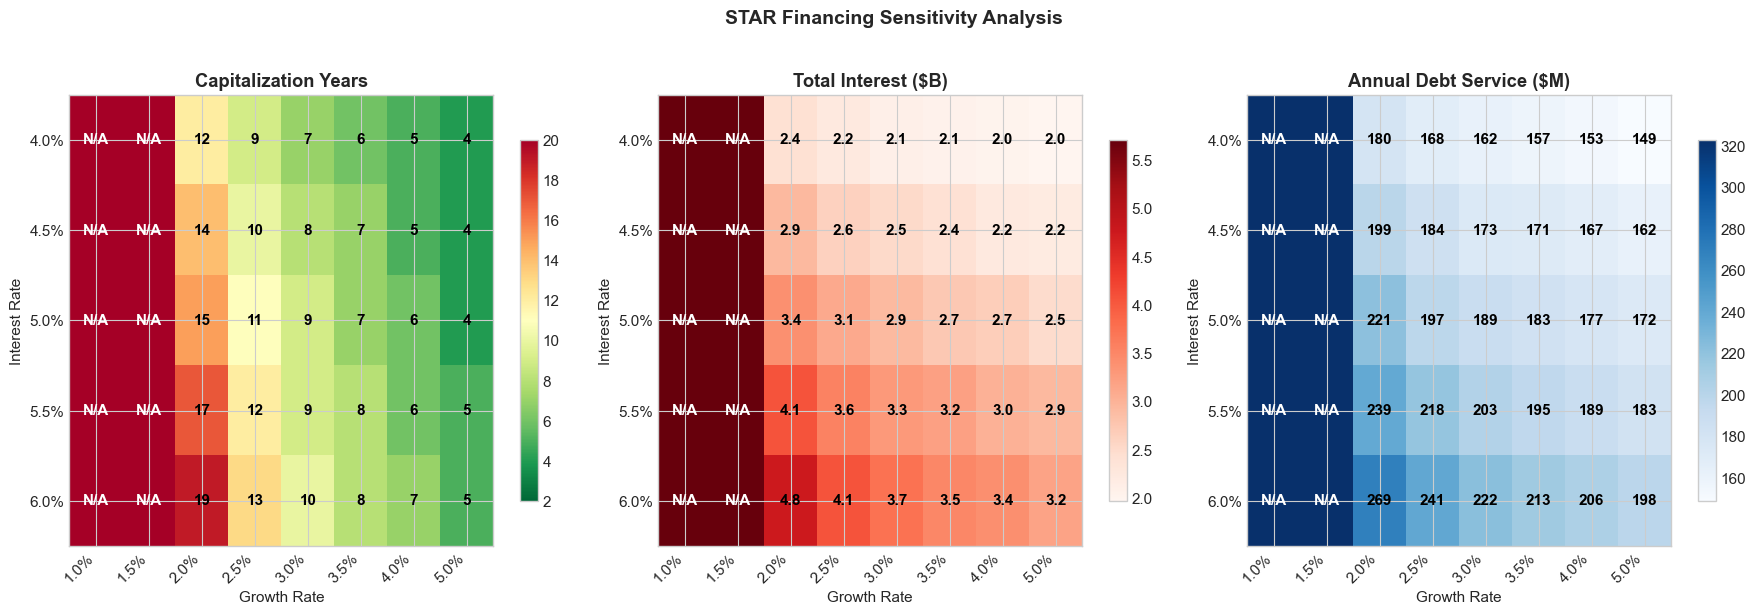


Sensitivity heatmaps saved to: data/star_sensitivity_heatmaps.png


In [19]:
# =============================================================================
# SENSITIVITY HEATMAPS
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

pivot_cap = sensitivity_df.pivot(index='interest_rate', columns='growth_rate', values='cap_years')
pivot_int = sensitivity_df.pivot(index='interest_rate', columns='growth_rate', values='total_interest_B')
pivot_ds = sensitivity_df.pivot(index='interest_rate', columns='growth_rate', values='debt_service_M')

# Heatmap 1: Cap Years
cap_vals = pivot_cap.values.astype(float)
cap_display = np.where(np.isnan(cap_vals), MAX_CAP_YEARS, cap_vals)
im1 = axes[0].imshow(cap_display, cmap='RdYlGn_r', aspect='auto', vmin=2, vmax=MAX_CAP_YEARS)
axes[0].set_xticks(range(len(pivot_cap.columns)))
axes[0].set_xticklabels([f'{g:.1%}' for g in pivot_cap.columns], rotation=45, ha='right')
axes[0].set_yticks(range(len(pivot_cap.index)))
axes[0].set_yticklabels([f'{r:.1%}' for r in pivot_cap.index])
axes[0].set_xlabel('Growth Rate')
axes[0].set_ylabel('Interest Rate')
axes[0].set_title('Capitalization Years', fontweight='bold')
for i in range(len(pivot_cap.index)):
    for j in range(len(pivot_cap.columns)):
        val = cap_vals[i, j]
        txt = 'N/A' if np.isnan(val) else f'{val:.0f}'
        color = 'white' if np.isnan(val) else 'black'
        axes[0].text(j, i, txt, ha='center', va='center', color=color, fontweight='bold')
fig.colorbar(im1, ax=axes[0], shrink=0.8)

# Heatmap 2: Total Interest
int_vals = pivot_int.values.astype(float)
int_max = np.nanmax(int_vals) * 1.2 if not np.all(np.isnan(int_vals)) else 5
int_display = np.where(np.isnan(int_vals), int_max, int_vals)
im2 = axes[1].imshow(int_display, cmap='Reds', aspect='auto')
axes[1].set_xticks(range(len(pivot_int.columns)))
axes[1].set_xticklabels([f'{g:.1%}' for g in pivot_int.columns], rotation=45, ha='right')
axes[1].set_yticks(range(len(pivot_int.index)))
axes[1].set_yticklabels([f'{r:.1%}' for r in pivot_int.index])
axes[1].set_xlabel('Growth Rate')
axes[1].set_ylabel('Interest Rate')
axes[1].set_title('Total Interest ($B)', fontweight='bold')
for i in range(len(pivot_int.index)):
    for j in range(len(pivot_int.columns)):
        val = int_vals[i, j]
        txt = 'N/A' if np.isnan(val) else f'{val:.1f}'
        color = 'white' if np.isnan(val) else 'black'
        axes[1].text(j, i, txt, ha='center', va='center', color=color, fontweight='bold')
fig.colorbar(im2, ax=axes[1], shrink=0.8)

# Heatmap 3: Debt Service
ds_vals = pivot_ds.values.astype(float)
ds_max = np.nanmax(ds_vals) * 1.2 if not np.all(np.isnan(ds_vals)) else 300
ds_display = np.where(np.isnan(ds_vals), ds_max, ds_vals)
im3 = axes[2].imshow(ds_display, cmap='Blues', aspect='auto')
axes[2].set_xticks(range(len(pivot_ds.columns)))
axes[2].set_xticklabels([f'{g:.1%}' for g in pivot_ds.columns], rotation=45, ha='right')
axes[2].set_yticks(range(len(pivot_ds.index)))
axes[2].set_yticklabels([f'{r:.1%}' for r in pivot_ds.index])
axes[2].set_xlabel('Growth Rate')
axes[2].set_ylabel('Interest Rate')
axes[2].set_title('Annual Debt Service ($M)', fontweight='bold')
for i in range(len(pivot_ds.index)):
    for j in range(len(pivot_ds.columns)):
        val = ds_vals[i, j]
        txt = 'N/A' if np.isnan(val) else f'{val:.0f}'
        color = 'white' if np.isnan(val) else 'black'
        axes[2].text(j, i, txt, ha='center', va='center', color=color, fontweight='bold')
fig.colorbar(im3, ax=axes[2], shrink=0.8)

plt.suptitle('STAR Financing Sensitivity Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/star_sensitivity_heatmaps.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\nSensitivity heatmaps saved to: data/star_sensitivity_heatmaps.png")

---
## 7. Export Results

In [20]:
# =============================================================================
# EXPORT TO EXCEL
# =============================================================================

# Build parameters list
params_list = [
    ('Principal', f'${PRINCIPAL:,.0f}'),
    ('Interest Rate', f'{INTEREST_RATE:.2%}'),
    ('Term (Years)', TERM_YEARS),
    ('Coverage Ratio', f'{COVERAGE_RATIO:.2f}x'),
    ('', ''),
    ('--- STATE TAX STREAMS ---', ''),
    ('Sales+Use Base', f'${SALES_USE_TAX_BASE:,.0f}'),
    ('Sales+Use Growth', f'{SALES_USE_TAX_GROWTH:.2%}'),
    ('', ''),
    ('--- ALCOHOL/GAMING ---', ''),
    ('LET Base', f'${LET_BASE:,.0f}'),
    ('LET Growth', f'{LET_GROWTH:.2%}'),
    ('Liquor Excise Base', f'${LIQUOR_EXCISE_BASE:,.0f}'),
    ('Liquor Excise Growth', f'{LIQUOR_EXCISE_GROWTH:.2%}'),
    ('APSK Base', f'${APSK_STATE_REVENUE:,.0f}'),
    ('APSK Pledge %', f'{APSK_PLEDGE_PCT:.0%}'),
    ('APSK Growth', f'{APSK_GROWTH:.2%}'),
]

# Add local add-ins if included
if INCLUDE_LOCAL_ADD_INS:
    params_list.extend([
        ('', ''),
        ('--- LOCAL ADD-INS ---', ''),
        ('Include Local Add-Ins', 'YES'),
        ('Olathe Combined Base', f'${OLATHE_COMBINED_BASE:,.0f}'),
        ('Olathe Growth', f'{OLATHE_GROWTH:.2%}'),
        ('Wyandotte UG Combined Base', f'${UG_COMBINED_BASE:,.0f}'),
        ('Wyandotte UG Growth', f'{UG_GROWTH:.2%}'),
        ('Total Local Add-In Base', f'${TOTAL_LOCAL_ADD_IN_BASE:,.0f}'),
    ])
else:
    params_list.extend([
        ('', ''),
        ('--- LOCAL ADD-INS ---', ''),
        ('Include Local Add-Ins', 'NO'),
    ])

params_df = pd.DataFrame(params_list, columns=['Parameter', 'Value'])

with pd.ExcelWriter('data/star_financing_results.xlsx', engine='openpyxl') as writer:
    
    # Parameters sheet
    params_df.to_excel(writer, sheet_name='Parameters', index=False)
    
    # Amortization schedule
    df.to_excel(writer, sheet_name='Amortization Schedule', index=False)
    
    # Sensitivity analysis
    sensitivity_df.to_excel(writer, sheet_name='Sensitivity Analysis', index=False)
    
    # Summary
    summary_df = pd.DataFrame([summary])
    summary_df.to_excel(writer, sheet_name='Summary', index=False)

print("Results exported to: data/star_financing_results.xlsx")
print("\nSheets:")
print("  - Parameters: Input assumptions (including local add-ins)")
print("  - Amortization Schedule: Year-by-year cash flows")
print("  - Sensitivity Analysis: Interest rate × growth rate matrix")
print("  - Summary: Key results")

Results exported to: data/star_financing_results.xlsx

Sheets:
  - Parameters: Input assumptions (including local add-ins)
  - Amortization Schedule: Year-by-year cash flows
  - Sensitivity Analysis: Interest rate × growth rate matrix
  - Summary: Key results
